Estimate TE between pairs of regions around ripples

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import regions as rg
import frites
import xarray as xr
import ISRUtilities as isru
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/FinalFigures'

/home/pietro/uvEnvs/frites/lib/python3.12/site-packages/frites/io/io_syslog.py:49: SyntaxWarning: invalid escape sequence '\*'
  regexp = '\*.*?\*'


In [34]:
def _regionRippleTE(session,regs=None,n_shuffle=0):
    # estimate transfer entropy (TE) across regions around ripple peak times as (shuffle, region, lag) XArray
    # 'shuffle' coordinate is False iff corresponding data values are real

    R = rg.data.Regions(session,states='sws',events=['InfraSlowRhythm/slownr','InfraSlowRhythm/slowavalnr','ripples'])
    regs = R.ids if regs is None else np.array(regs)
    is_reg = np.isin(regs,R.ids) # is_reg[i] is True if regs[i] is in R.ids SHOULD USE THIS
    rip_time = R.eventInfo('ripples')[:,2]
    firing_rate = R.firingRate()

    # IEI SHUFFLE
    shuffled_rip_time = np.zeros((len(rip_time),n_shuffle+1)) # each column is a shuffle, first is observed
    shuffled_rip_time[:,0] = rip_time
    for i in range(n_shuffle):
        shuffled_rip_time[:,i+1] = fma.general.shuffleEvents(rip_time,intervals=R.eventIntervals('sws'))

    TE = []
    for i in range(n_shuffle+1):
        rip_peth, t, _ = fma.analysis.PETH(firing_rate,shuffled_rip_time[:,i],limits=[-0.5,0.5],n_bins=101)
        TE.append(frites.conn.conn_te(np.transpose(rip_peth,(0,2,1)),t,R.ids,verbose=False))
    shuffle = xr.DataArray([False]+[True]*n_shuffle,dims='shuffle')
    xdata = xr.concat(TE,dim=shuffle)

    return xdata

In [2]:
def _regionRippleTEShift(session,regs=None,n_shuffle=0,rnd_seed=None):
    # estimate transfer entropy (TE) across regions around ripple peak times as (shuffle, region, lag) XArray
    # surrogate data is produced by circular shift of ripples, 'shuffle' coordinate is False iff corresponding data values are real

    R = rg.data.Regions(session,states='sws',events=['InfraSlowRhythm/slownr','InfraSlowRhythm/slowavalnr','ripples'])
    regs = R.ids if regs is None else np.array(regs)
    is_reg = np.isin(regs,R.ids) # is_reg[i] is True if regs[i] is in R.ids SHOULD USE THIS
    rip_time = R.eventInfo('ripples')[:,2]
    firing_rate = R.firingRate()

    rip_peth, t, _ = fma.analysis.PETH(firing_rate,rip_time,limits=[-0.5,0.5],n_bins=101)
    rip_peth = np.transpose(rip_peth,(0,2,1)) # (ripples, region, times)
    TE = [frites.conn.conn_te(rip_peth,t,R.ids,verbose=False)]

    # circular shuffle
    n_ripples, n_regs, n_times = rip_peth.shape
    rng = np.random.default_rng(rnd_seed)
    shift = rng.integers(-5,5,size=(n_shuffle,n_regs)) # shift[i,j] is used to roll region j at shuffle i
    for i in range(n_shuffle):
        idx = (np.arange(n_ripples)[:,None] - shift[i,:]) % n_ripples # idx[:,j] shifts the ripple axis for region j
        shifted_peth = rip_peth[idx,np.arange(n_regs),:]
        TE.append(frites.conn.conn_te(shifted_peth,t,R.ids,verbose=False))

    shuffle = xr.DataArray([False]+[True]*n_shuffle,dims='shuffle')
    xdata = xr.concat(TE,dim=shuffle)

    return xdata, shift

In [3]:
# parameters
regs = ['hpc','nr','pfc']
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_units.batch'

In [ ]:
session = fma.data.readBatchFile(batch_file)[0][25]
print(f'session: {session}')
xsession, _ = _regionRippleTEShift(session,regs,n_shuffle=20,rnd_seed='aaa')

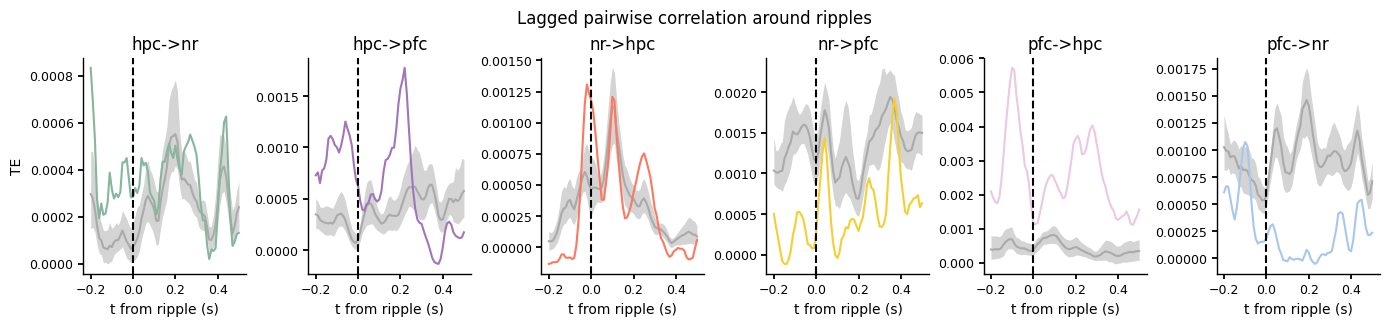

In [5]:
fig, axs = fma.plotting.makeFigure('Lagged pairwise correlation around ripples',[1,6],[35,8])
for i, r in enumerate(xsession['roi']):
    reg_data = xsession.sel(roi=r)
    fma.plotting.semPlot(xsession['times'],reg_data.sel(shuffle=True),zscore=False,color='#AAAAAA',label=str(r.item().upper()),ax=axs[i])
    axs[i].plot(xsession['times'],reg_data.sel(shuffle=False),color=isru.paperColors(i),label=str(r.item().upper()))
    axs[i].set_xlabel('t from ripple (s)'), axs[i].set_title(r.values)
    axs[i].axvline(0,ls='--',color='k')
axs[0].set_ylabel('TE');

run batch

In [6]:
xdata, shifts = fma.data.runBatch(batch_file,_regionRippleTEShift,kwargs={'regs': regs,'n_shuffle': 200},rnd_seed='rnd_seed',ignore_args=True,parallel=True)


Starting Batch, 2026-06-09 18:26:54.615836 

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230815/Rat002_20230815.xml (34)
/mnt/hubel-data-148/blinky/Training/Rat002_20230815/Rat002_20230815.ripples not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230816/Rat002_20230816.xml (35)
/mnt/hubel-data-148/blinky/Training/Rat002_20230816/Rat002_20230816.ripples not found.
Traceback:
Error 

In [7]:
# concatenate data
data_cat = xr.concat([d for d in xdata if d is not None],dim='session')
# grand-average statistical test
pval = {r.item(): fma.analysis.maxStatisticTest(data_cat.sel(roi=r,shuffle=False),
        data_cat.sel(roi=r,shuffle=True).transpose('session','times',...)) for r in data_cat.roi}

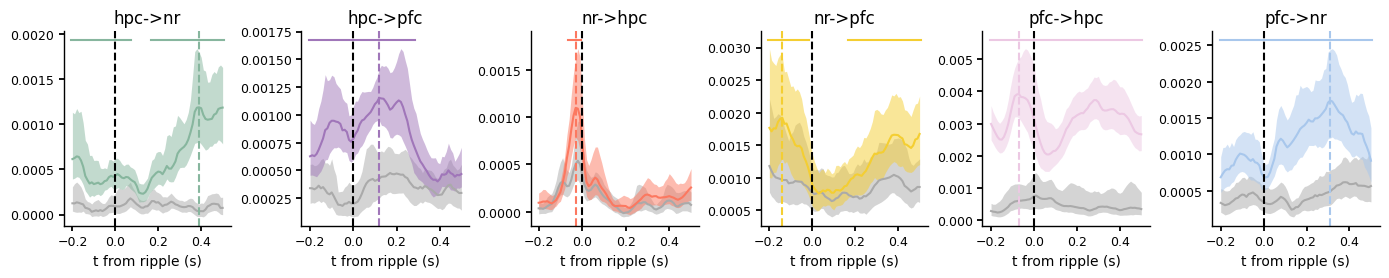

In [8]:
# DO: ISR vs nISR and CHECK JUST sleep2 FIRST 20 min!!! I COULD MAYBE EXPLORE min_delay max_delay
# meaning A->B : for a certain t, amount of help given by A to predict what B does (across ripples)
fig, axs = fma.plotting.makeFigure('',[1,6],size=[35,7])
for i, r in enumerate(data_cat['roi'].values):
    reg_data = data_cat.sel(roi=r)
    fma.plotting.semPlot(data_cat['times'],reg_data.isel(shuffle=10),zscore=False,color='#AAAAAA',label=r.upper(),ax=axs[i])
    #fma.plotting.semPlot(data_cat['times'],reg_data.stack(d=('session','shuffle')).transpose('d','times'),zscore=False,color='#AAAAAA',label=r.upper(),ax=axs[i])
    fma.plotting.semPlot(data_cat['times'],reg_data.sel(shuffle=False),zscore=False,color=isru.paperColors(i),label=r.upper(),ax=axs[i])
    peak_time = np.argmax(reg_data.sel(shuffle=False).mean('session').data)
    axs[i].axvline(reg_data.times[peak_time],ls='--',color=isru.paperColors(i)),
    axs[i].axvline(0,ls='--',color='k'), axs[i].set_xlabel('t from ripple (s)'), axs[i].set_title(r)
    # statistical significance
    fma.plotting.pHorzLine(pval[r],data_cat['times'],color=isru.paperColors(i),ax=axs[i])
#fma.plotting.saveFigure(fig,froot/'ISRipplesSpindles/3l_fr_rip_TE',['svg','png'])